In [ ]:
import numpy as np
from tangermeme.plot import plot_logo

import tfmindi as tm

In [2]:
sample_oh = np.load("tests/data/sample_oh.npz")["oh"]
sample_contrib = np.load("tests/data/sample_contrib.npz")["contrib"]

In [3]:
seqlets_df, seqlet_matrices = tm.pp.extract_seqlets(sample_contrib, sample_oh, threshold=0.05)
print(seqlets_df.head())
print(len(seqlet_matrices))

Processing seqlets: 100%|██████████| 264/264 [00:00<00:00, 21953.18it/s]

   example_idx  start  end  attribution   p-value
0           31    235  251    -0.199164  0.000609
1           24     57   77    -0.480713  0.003419
2           27     82   97    -0.209176  0.003568
3           21    307  324     0.730987  0.004627
4           31    218  232    -0.076939  0.004637
264


In [ ]:
import seaborn
from matplotlib import pyplot as plt

seaborn.set_style("whitegrid")

In [6]:
from tangermeme.seqlet import recursive_seqlets

tangermeme_seqlets = recursive_seqlets((sample_contrib * sample_oh).sum(1), threshold=0.05)

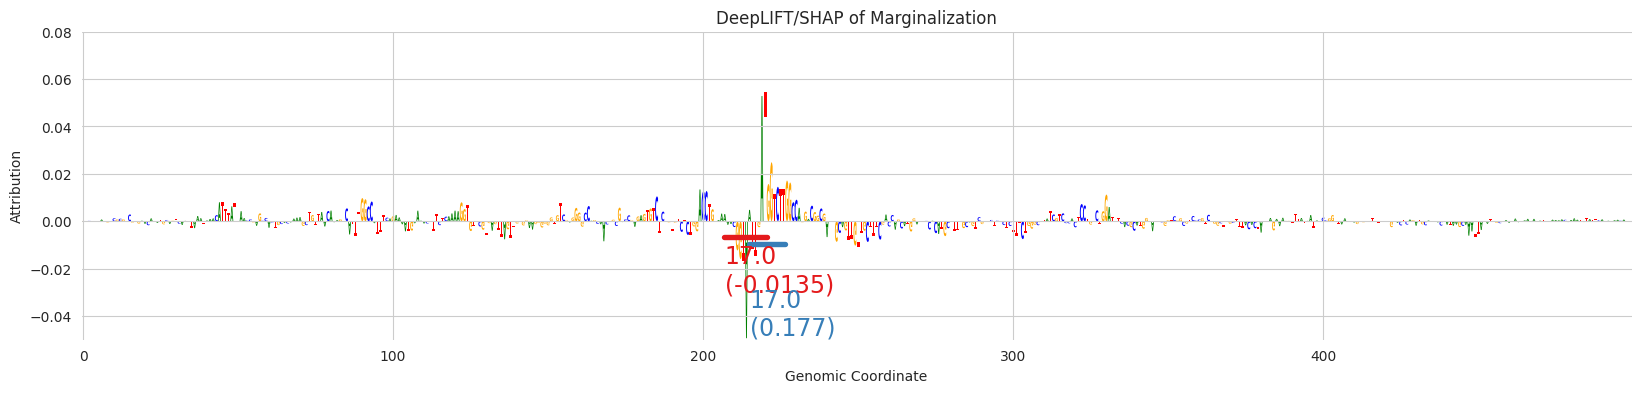

In [13]:
idx = 17
plt.figure(figsize=(20, 4))
ax = plt.subplot(111)
plot_logo(
    sample_contrib[idx, :, :] * sample_oh[idx, :, :],
    ax=ax,
    annotations=seqlets_df[seqlets_df["example_idx"] == idx],
    score_key="attribution",
)
plt.ylim(-0.05, 0.08)

plt.xlabel("Genomic Coordinate")
plt.ylabel("Attribution")
plt.title("DeepLIFT/SHAP of Marginalization")
plt.show()

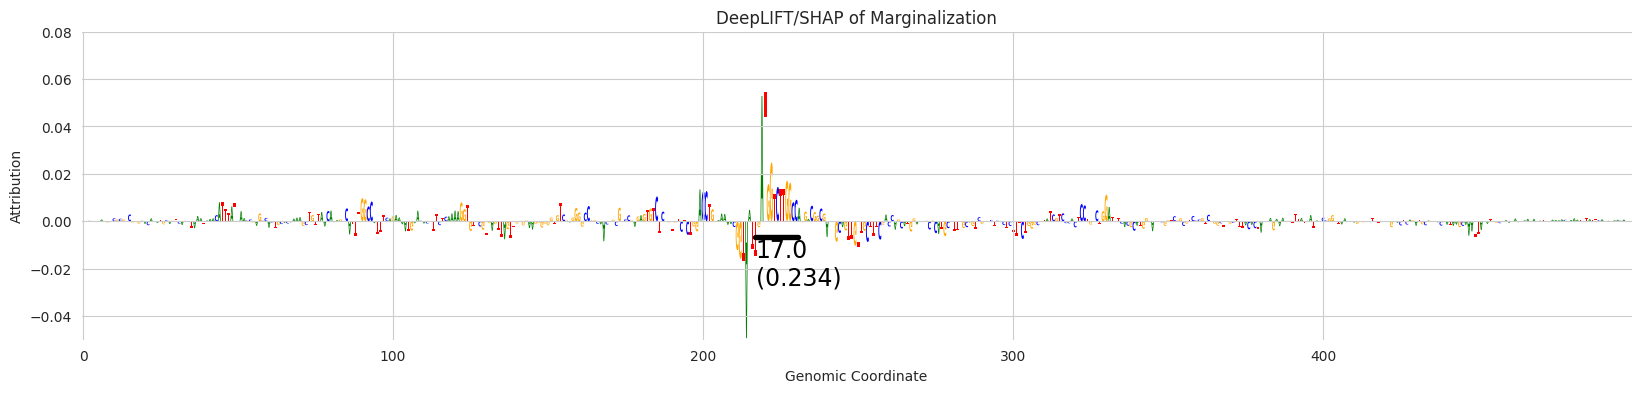

In [14]:
plt.figure(figsize=(20, 4))
ax = plt.subplot(111)
plot_logo(
    sample_contrib[idx, :, :] * sample_oh[idx, :, :],
    ax=ax,
    annotations=tangermeme_seqlets[tangermeme_seqlets["example_idx"] == idx],
    score_key="attribution",
)
plt.ylim(-0.05, 0.08)

plt.xlabel("Genomic Coordinate")
plt.ylabel("Attribution")
plt.title("DeepLIFT/SHAP of Marginalization")
plt.show()